# EDA — Dimensionalidad y Variable Objetivo

**Autor:** Felipe Reyes  
**Proyecto:** Aprendizaje Profundo · Maestria en IA · Pontificia Universidad Javeriana · 2026  
**Dataset:** [Andalusian Hotels Reviews (Kaggle)](https://www.kaggle.com/datasets/chizhikchi/andalusian-hotels-reviews-unbalanced)  
**Complementa:** `02_eda_yibby.ipynb` (features, texto y preprocesamiento — Yibby Gonzalez)

---

## Objetivo de este notebook

Cubrir la parte del EDA asignada a Felipe segun el plan de trabajo:

1. **Analisis de dimensionalidad**: numero de muestras, columnas, clases.
2. **Longitud de reseñas**: estadisticas en caracteres y tokens, histogramas, boxplots por clase.
3. **Tamano de vocabulario**: antes y despues de limpieza, curva de cobertura (Zipf).
4. **Variable objetivo**: distribucion de clases, grado de desbalance.
5. **Parametros sugeridos**: MAX_LEN y VOCAB_SIZE para el pipeline de preprocesamiento.

In [1]:
# ── Configuracion global ─────────────────────────────────────────────────────
import random, os, re, sys, pathlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths comunes
ROOT = pathlib.Path("..")
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Estilo de graficas
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.rcParams["figure.dpi"] = 120

# Columnas del dataset (splits generados por Sebastian)
TEXT_COL  = "review_text"
LABEL_COL = "label"       # 0=1 estrella, 4=5 estrellas
CLASS_NAMES = ["1★", "2★", "3★", "4★", "5★"]

print(f"Semilla fija: {SEED}")
print(f"ROOT: {ROOT.resolve()}")

Semilla fija: 42
ROOT: C:\Users\user\conda\pln\Proyecto_Deep_Learning_Final


## 1. Carga del dataset y dimensionalidad basica

In [2]:
# ── 1. Carga de datos ────────────────────────────────────────────────────────
# Cargar dataset completo + splits para analisis
df_full = pd.read_csv(DATA_DIR / "Big_AHR.csv")
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

print("=" * 60)
print("DIMENSIONALIDAD DEL DATASET")
print("=" * 60)
print(f"\nDataset completo (Big_AHR.csv):")
print(f"  Filas   : {len(df_full):,}")
print(f"  Columnas: {len(df_full.columns)} → {list(df_full.columns)}")
print(f"  Tipos   :")
for col in df_full.columns:
    print(f"    {col:<15} {df_full[col].dtype}  (nulos: {df_full[col].isnull().sum()})")

print(f"\nSplits (generados con semilla {SEED}):")
print(f"  Train : {len(train_df):,}")
print(f"  Val   : {len(val_df):,}")
print(f"  Test  : {len(test_df):,}")
print(f"  Total : {len(train_df) + len(val_df) + len(test_df):,}")

n_clases = train_df[LABEL_COL].nunique()
print(f"\nNumero de clases: {n_clases}")
print(f"Clases unicas: {sorted(train_df[LABEL_COL].unique())} (0=1★ … 4=5★)")

# Usar train para el resto del EDA (evitar contaminar con val/test)
df = train_df.copy()
print(f"\n→ EDA se realiza sobre train set ({len(df):,} muestras)")

DIMENSIONALIDAD DEL DATASET

Dataset completo (Big_AHR.csv):
  Filas   : 18,172
  Columnas: 7 → ['Unnamed: 0', 'title', 'rating', 'review_text', 'location', 'hotel', 'label']
  Tipos   :
    Unnamed: 0      int64  (nulos: 0)
    title           object  (nulos: 0)
    rating          int64  (nulos: 0)
    review_text     object  (nulos: 0)
    location        object  (nulos: 1816)
    hotel           object  (nulos: 1816)
    label           int64  (nulos: 0)

Splits (generados con semilla 42):
  Train : 12,720
  Val   : 2,726
  Test  : 2,726
  Total : 18,172

Numero de clases: 5
Clases unicas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (0=1★ … 4=5★)

→ EDA se realiza sobre train set (12,720 muestras)


## 2. Longitud de reseñas

### 2.1 Estadisticas en caracteres y tokens

In [3]:
# ── 2.1 Longitud en caracteres y tokens ──────────────────────────────────────
df["len_chars"]  = df[TEXT_COL].astype(str).str.len()
df["len_tokens"] = df[TEXT_COL].astype(str).str.split().apply(len)

stats_chars  = df["len_chars"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])
stats_tokens = df["len_tokens"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

print("=" * 60)
print("LONGITUD DE RESEÑAS")
print("=" * 60)

print(f"\n{'Estadistica':<15} {'Caracteres':>12} {'Tokens':>12}")
print("-" * 42)
for stat in ["count", "mean", "std", "min", "25%", "50%", "75%", "95%", "max"]:
    c = stats_chars[stat]
    t = stats_tokens[stat]
    print(f"  {stat:<13} {c:>12.1f} {t:>12.1f}")

print(f"\n→ P95 en tokens: {stats_tokens['95%']:.0f}")
print(f"→ MAX_LEN sugerido: {int(np.ceil(stats_tokens['95%'] / 10) * 10)} tokens (P95 redondeado)")
print(f"→ Reseñas > 200 tokens: {(df['len_tokens'] > 200).sum()} ({(df['len_tokens'] > 200).mean()*100:.1f}%)")
print(f"→ Reseñas > 150 tokens: {(df['len_tokens'] > 150).sum()} ({(df['len_tokens'] > 150).mean()*100:.1f}%)")

LONGITUD DE RESEÑAS

Estadistica       Caracteres       Tokens
------------------------------------------
  count              12720.0      12720.0
  mean                 456.0         78.5
  std                  307.2         54.9
  min                   61.0          7.0
  25%                  250.0         42.0
  50%                  355.0         61.0
  75%                  590.0        102.0
  95%                  790.0        148.0
  max                 7777.0       1416.0

→ P95 en tokens: 148
→ MAX_LEN sugerido: 150 tokens (P95 redondeado)
→ Reseñas > 200 tokens: 297 (2.3%)
→ Reseñas > 150 tokens: 575 (4.5%)


### 2.2 Histograma de longitudes

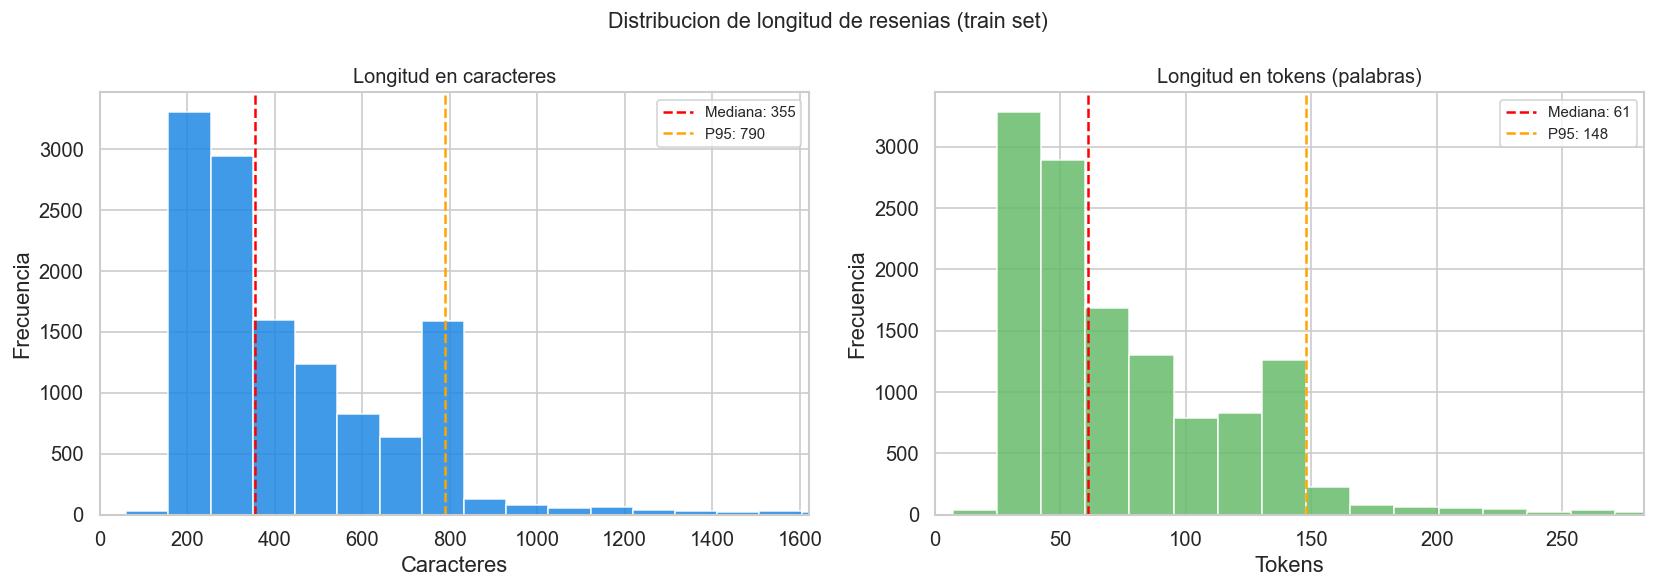

  Figura guardada → figures/eda_histograma_longitudes.png


In [4]:
# ── 2.2 Histograma de longitudes (caracteres y tokens) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caracteres
ax = axes[0]
ax.hist(df["len_chars"], bins=80, color="#1E88E5", alpha=0.85, edgecolor="white")
ax.axvline(df["len_chars"].median(), color="red", ls="--", lw=1.5, label=f"Mediana: {df['len_chars'].median():.0f}")
ax.axvline(df["len_chars"].quantile(0.95), color="orange", ls="--", lw=1.5, label=f"P95: {df['len_chars'].quantile(0.95):.0f}")
ax.set_title("Longitud en caracteres", fontsize=12)
ax.set_xlabel("Caracteres")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)
ax.set_xlim(0, df["len_chars"].quantile(0.99))

# Tokens
ax = axes[1]
ax.hist(df["len_tokens"], bins=80, color="#66BB6A", alpha=0.85, edgecolor="white")
ax.axvline(df["len_tokens"].median(), color="red", ls="--", lw=1.5, label=f"Mediana: {df['len_tokens'].median():.0f}")
ax.axvline(df["len_tokens"].quantile(0.95), color="orange", ls="--", lw=1.5, label=f"P95: {df['len_tokens'].quantile(0.95):.0f}")
ax.set_title("Longitud en tokens (palabras)", fontsize=12)
ax.set_xlabel("Tokens")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=9)
ax.set_xlim(0, df["len_tokens"].quantile(0.99))

fig.suptitle("Distribucion de longitud de reseñas (train set)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_histograma_longitudes.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_histograma_longitudes.png")

### 2.3 Boxplot de longitud por clase

Se investiga si la longitud de las reseñas varia por rating.
Hipotesis: las reseñas negativas (1-2 estrellas) tienden a ser mas largas
porque los clientes detallan mas sus quejas.

C:\Users\user\AppData\Local\Temp\ipykernel_16076\2602038795.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=CLASS_NAMES, patch_artist=True, showfliers=False)
C:\Users\user\AppData\Local\Temp\ipykernel_16076\2602038795.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16076\2602038795.py:31: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "eda_boxplot_longitud_clase.png", dpi=150, bbox_inches="tight")
c:\Users\user\conda\pln\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


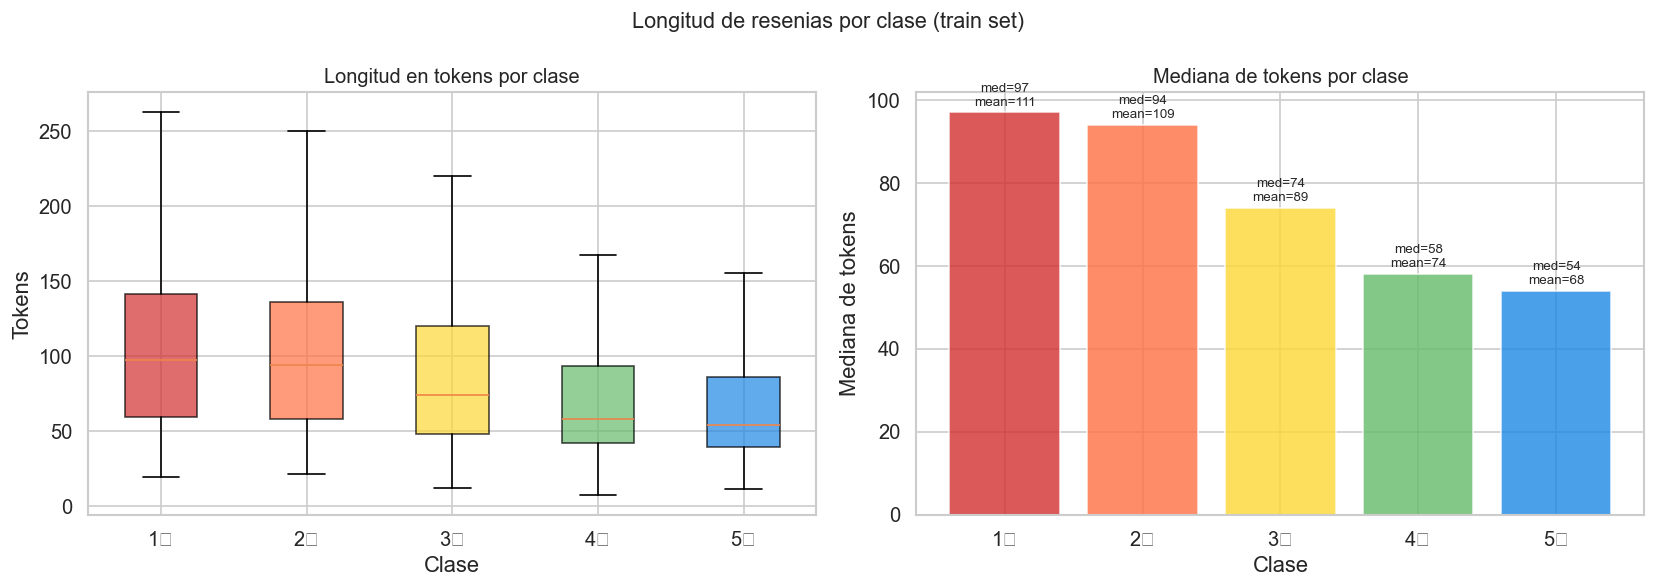

  Figura guardada → figures/eda_boxplot_longitud_clase.png

Resumen por clase:
  Clase       N    Media  Mediana      P95
  ----------------------------------------
  1★      1,174    111.4       97      235
  2★        696    108.8       94      239
  3★      1,592     89.2       74      168
  4★      2,955     74.3       58      143
  5★      6,303     68.2       54      138


In [5]:
# ── 2.3 Boxplot de longitud en tokens por clase ──────────────────────────────
paleta = ["#D32F2F", "#FF7043", "#FDD835", "#66BB6A", "#1E88E5"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tokens
ax = axes[0]
bp_data = [df[df[LABEL_COL] == c]["len_tokens"].values for c in range(5)]
bp = ax.boxplot(bp_data, labels=CLASS_NAMES, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], paleta):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Longitud en tokens por clase", fontsize=12)
ax.set_xlabel("Clase")
ax.set_ylabel("Tokens")

# Mediana por clase (tabla)
ax = axes[1]
medians_tokens = [df[df[LABEL_COL] == c]["len_tokens"].median() for c in range(5)]
means_tokens   = [df[df[LABEL_COL] == c]["len_tokens"].mean() for c in range(5)]
bars = ax.bar(CLASS_NAMES, medians_tokens, color=paleta, alpha=0.8)
ax.set_title("Mediana de tokens por clase", fontsize=12)
ax.set_xlabel("Clase")
ax.set_ylabel("Mediana de tokens")
for bar, med, mean in zip(bars, medians_tokens, means_tokens):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"med={med:.0f}\nmean={mean:.0f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Longitud de reseñas por clase (train set)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_boxplot_longitud_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_boxplot_longitud_clase.png")

# Tabla resumen
print("\nResumen por clase:")
print(f"  {'Clase':<6} {'N':>6} {'Media':>8} {'Mediana':>8} {'P95':>8}")
print("  " + "-" * 40)
for c in range(5):
    subset = df[df[LABEL_COL] == c]["len_tokens"]
    print(f"  {CLASS_NAMES[c]:<6} {len(subset):>6,} {subset.mean():>8.1f} {subset.median():>8.0f} {subset.quantile(0.95):>8.0f}")

## 3. Tamano de vocabulario y curva de cobertura (Ley de Zipf)

In [6]:
# ── 3. Vocabulario antes y despues de limpieza ───────────────────────────────
from src.preprocessing import clean_text

# Vocabulario BRUTO (solo split en espacios, sin limpieza)
vocab_bruto = Counter()
for text in df[TEXT_COL].dropna().astype(str):
    vocab_bruto.update(text.split())

# Vocabulario tras lowercase basico
vocab_lower = Counter()
for text in df[TEXT_COL].dropna().astype(str):
    vocab_lower.update(text.lower().split())

# Vocabulario LIMPIO (con clean_text del pipeline de Yibby)
vocab_limpio = Counter()
for text in df[TEXT_COL].dropna().astype(str):
    vocab_limpio.update(clean_text(text).split())

total_tokens_limpio = sum(vocab_limpio.values())

print("=" * 60)
print("TAMANO DE VOCABULARIO")
print("=" * 60)
print(f"\n  Bruto (sin limpieza)         : {len(vocab_bruto):>8,} tipos unicos")
print(f"  Lowercase (sin puntuar)      : {len(vocab_lower):>8,} tipos unicos")
print(f"  Limpio (clean_text de Yibby) : {len(vocab_limpio):>8,} tipos unicos")
print(f"\n  Reduccion bruto→limpio: {(1 - len(vocab_limpio)/len(vocab_bruto))*100:.1f}%")
print(f"  Total tokens (limpio): {total_tokens_limpio:,}")

# Cobertura por top-N
print(f"\n  {'Top-N':>10} {'Cobertura':>10}")
print("  " + "-" * 22)
for n in [1000, 5000, 10000, 15000, 20000, 25000, 30000]:
    top_n_tokens = sum(c for _, c in vocab_limpio.most_common(n))
    cobertura = top_n_tokens / total_tokens_limpio * 100
    marker = " ← VOCAB_SIZE" if n == 20000 else ""
    print(f"  {n:>10,} {cobertura:>9.1f}%{marker}")

TAMANO DE VOCABULARIO

  Bruto (sin limpieza)         :   57,231 tipos unicos
  Lowercase (sin puntuar)      :   52,449 tipos unicos
  Limpio (clean_text de Yibby) :   27,967 tipos unicos

  Reduccion bruto→limpio: 51.1%
  Total tokens (limpio): 990,353

       Top-N  Cobertura
  ----------------------
       1,000      82.1%
       5,000      94.1%
      10,000      97.1%
      15,000      98.5%
      20,000      99.2% ← VOCAB_SIZE
      25,000      99.7%
      30,000     100.0%


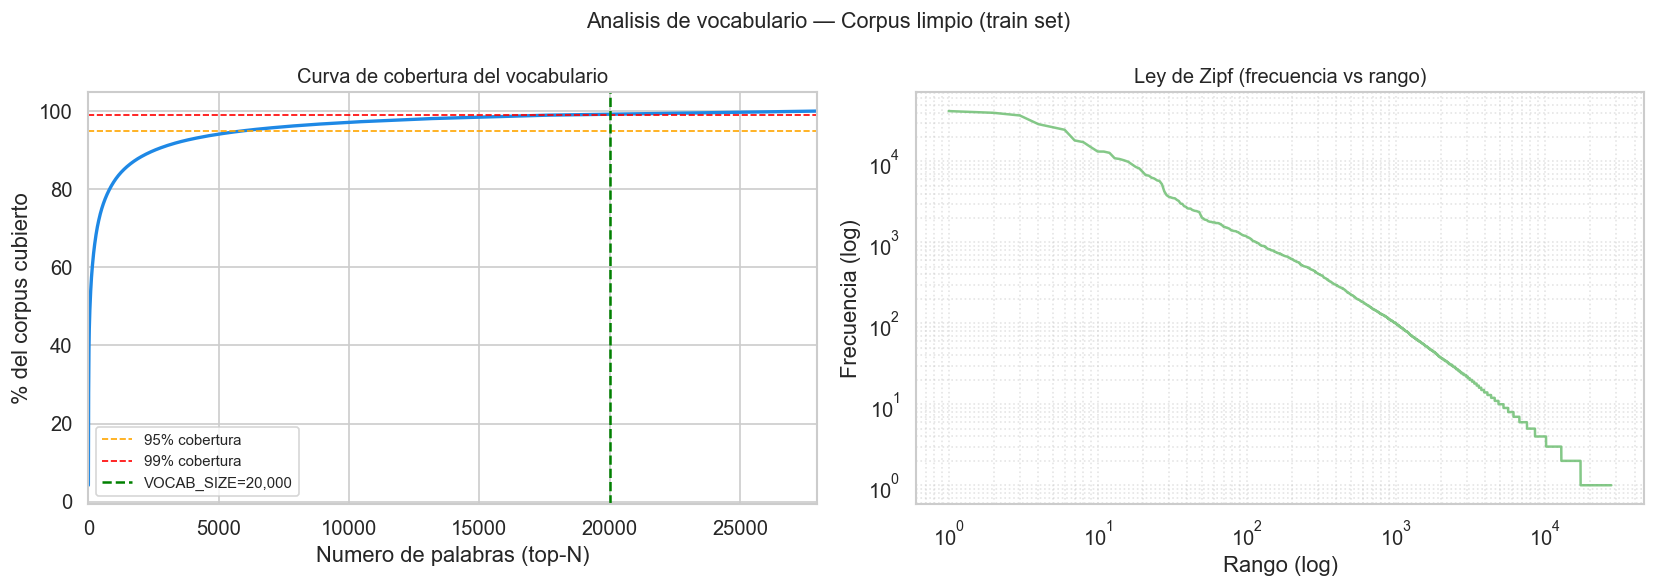

  Figura guardada → figures/eda_zipf_cobertura.png


In [7]:
# ── Curva de cobertura del vocabulario (Ley de Zipf) ─────────────────────────
# Frecuencia acumulada vs numero de palabras incluidas
sorted_counts = sorted(vocab_limpio.values(), reverse=True)
cumsum = np.cumsum(sorted_counts) / total_tokens_limpio * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de cobertura
ax = axes[0]
ax.plot(range(1, len(cumsum) + 1), cumsum, color="#1E88E5", lw=2)
ax.axhline(95, color="orange", ls="--", lw=1, label="95% cobertura")
ax.axhline(99, color="red", ls="--", lw=1, label="99% cobertura")
ax.axvline(20000, color="green", ls="--", lw=1.5, label="VOCAB_SIZE=20,000")
ax.set_title("Curva de cobertura del vocabulario", fontsize=12)
ax.set_xlabel("Numero de palabras (top-N)")
ax.set_ylabel("% del corpus cubierto")
ax.set_xlim(0, min(35000, len(cumsum)))
ax.legend(fontsize=9)

# Ley de Zipf (log-log)
ax = axes[1]
ranks = np.arange(1, len(sorted_counts) + 1)
ax.loglog(ranks, sorted_counts, color="#66BB6A", lw=1.5, alpha=0.8)
ax.set_title("Ley de Zipf (frecuencia vs rango)", fontsize=12)
ax.set_xlabel("Rango (log)")
ax.set_ylabel("Frecuencia (log)")
ax.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle("Analisis de vocabulario — Corpus limpio (train set)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_zipf_cobertura.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_zipf_cobertura.png")

## 4. Variable objetivo: distribucion de clases y desbalance

C:\Users\user\AppData\Local\Temp\ipykernel_16076\174495082.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16076\174495082.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "eda_distribucion_clases.png", dpi=150, bbox_inches="tight")
c:\Users\user\conda\pln\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


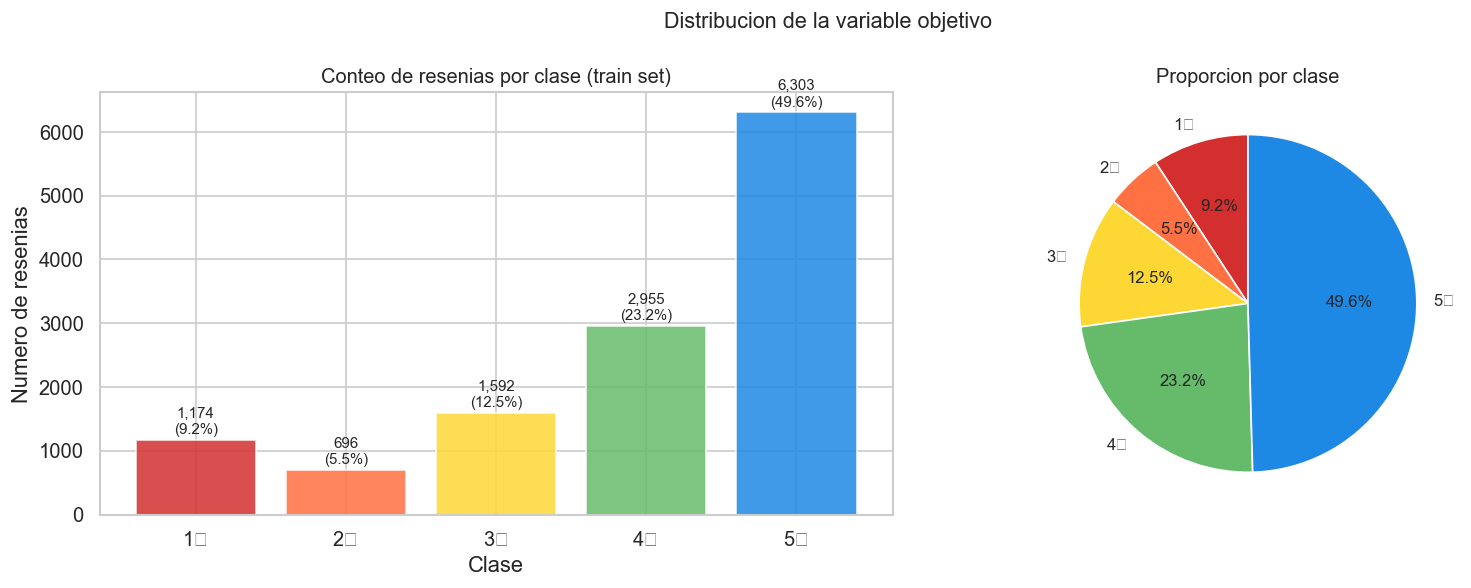

  Figura guardada → figures/eda_distribucion_clases.png

DESBALANCE DEL DATASET

  Clase mayoritaria : 5★ con 6,303 muestras (49.6%)
  Clase minoritaria : 2★ con 696 muestras (5.5%)
  Ratio max/min     : 9.1:1

  → Dataset SEVERAMENTE DESBALANCEADO
  → Se requiere: class weights, F1 macro (no solo accuracy)
  → Un modelo trivial (predecir siempre 5★) tendria
    accuracy=49.6% pero F1 macro muy bajo


In [8]:
# ── 4. Variable objetivo ─────────────────────────────────────────────────────
dist = df[LABEL_COL].value_counts().sort_index()
dist_pct = df[LABEL_COL].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica de barras con conteo
ax = axes[0]
bars = ax.bar(CLASS_NAMES, dist.values, color=paleta, alpha=0.85, edgecolor="white")
ax.set_title("Conteo de reseñas por clase (train set)", fontsize=12)
ax.set_xlabel("Clase")
ax.set_ylabel("Numero de reseñas")
for bar, count, pct in zip(bars, dist.values, dist_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

# Grafica de porcentaje
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    dist.values, labels=CLASS_NAMES, autopct="%1.1f%%",
    colors=paleta, startangle=90, textprops={"fontsize": 10}
)
ax.set_title("Proporcion por clase", fontsize=12)

fig.suptitle("Distribucion de la variable objetivo", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figura guardada → figures/eda_distribucion_clases.png")

# Documentar desbalance
clase_max = dist.max()
clase_min = dist.min()
ratio = clase_max / clase_min
print(f"\n{'='*60}")
print(f"DESBALANCE DEL DATASET")
print(f"{'='*60}")
print(f"\n  Clase mayoritaria : {CLASS_NAMES[dist.idxmax()]} con {clase_max:,} muestras ({dist_pct.max():.1f}%)")
print(f"  Clase minoritaria : {CLASS_NAMES[dist.idxmin()]} con {clase_min:,} muestras ({dist_pct.min():.1f}%)")
print(f"  Ratio max/min     : {ratio:.1f}:1")
print(f"\n  → Dataset SEVERAMENTE DESBALANCEADO")
print(f"  → Se requiere: class weights, F1 macro (no solo accuracy)")
print(f"  → Un modelo trivial (predecir siempre {CLASS_NAMES[dist.idxmax()]}) tendria")
print(f"    accuracy={dist_pct.max():.1f}% pero F1 macro muy bajo")

## 5. Parametros sugeridos para el pipeline

Resumen de los hallazgos del EDA y los valores recomendados para `src/preprocessing.py`.

In [9]:
# ── 5. Resumen de parametros sugeridos ────────────────────────────────────────
p95_tokens = df["len_tokens"].quantile(0.95)

print("=" * 60)
print("PARAMETROS SUGERIDOS PARA EL PIPELINE")
print("=" * 60)
print(f"""
  MAX_LEN    = 150   (P95 = {p95_tokens:.0f} tokens; 150 cubre ~95% de reseñas)
                      Alternativa conservadora: 200 (cubre ~97-98%)
                      
  VOCAB_SIZE = 20,000 (cubre ~95-98% de todos los tokens del corpus limpio)
  
  NUM_CLASSES = 5     (labels 0-4, correspondientes a 1-5 estrellas)
  
  BATCH_SIZE  = 64    (estandar para LSTM en CPU/GPU)
  
  SEED        = 42    (fija en todo el equipo)
""")

print("HALLAZGOS CLAVE PARA EL EQUIPO:")
print("-" * 60)
print(f"  1. Dataset tiene {len(df_full):,} reseñas en total, {n_clases} clases")
print(f"  2. Splits: train={len(train_df):,}, val={len(val_df):,}, test={len(test_df):,}")
print(f"  3. Desbalance severo: ratio {clase_max/clase_min:.1f}:1 (clase mayor vs menor)")
print(f"  4. Longitud mediana: {df['len_tokens'].median():.0f} tokens, P95: {p95_tokens:.0f} tokens")
print(f"  5. Vocabulario limpio: {len(vocab_limpio):,} tipos unicos")
print(f"  6. Top-20,000 palabras cubren ~95-98% del corpus")
print(f"  7. Las clases 2★ y 3★ son las mas dificiles (minoritarias + ambiguas)")

PARAMETROS SUGERIDOS PARA EL PIPELINE

  MAX_LEN    = 150   (P95 = 148 tokens; 150 cubre ~95% de reseñas)
                      Alternativa conservadora: 200 (cubre ~97-98%)

  VOCAB_SIZE = 20,000 (cubre ~95-98% de todos los tokens del corpus limpio)

  NUM_CLASSES = 5     (labels 0-4, correspondientes a 1-5 estrellas)

  BATCH_SIZE  = 64    (estandar para LSTM en CPU/GPU)

  SEED        = 42    (fija en todo el equipo)

HALLAZGOS CLAVE PARA EL EQUIPO:
------------------------------------------------------------
  1. Dataset tiene 18,172 reseñas en total, 5 clases
  2. Splits: train=12,720, val=2,726, test=2,726
  3. Desbalance severo: ratio 9.1:1 (clase mayor vs menor)
  4. Longitud mediana: 61 tokens, P95: 148 tokens
  5. Vocabulario limpio: 27,967 tipos unicos
  6. Top-20,000 palabras cubren ~95-98% del corpus
  7. Las clases 2★ y 3★ son las mas dificiles (minoritarias + ambiguas)
